# Online Gaming Player Engagement Prediction

**Goal:** Predict **EngagementLevel** (`High`, `Medium`, `Low`) using player demographics + gameplay behavior metrics.

This notebook follows a full **end-to-end ML workflow**:
- Problem understanding
- Data loading + quality checks
- EDA (univariate, bivariate, multivariate)
- Feature engineering + preprocessing
- Baseline Decision Tree
- Evaluation (confusion matrix, accuracy, classification report)
- Hyperparameter tuning
- Tree pruning (cost-complexity pruning)
- Model comparison + final model selection



## 1) Problem Statement

Online games want to **retain players** and keep them engaged. If we can predict a player's engagement level early, we can:

- Identify players at risk of dropping engagement (e.g., `Low`)
- Trigger personalized offers / onboarding / difficulty adjustments
- Improve game design by understanding key drivers of engagement

**ML Task:** Multiclass classification
- **Input (X):** demographics + gameplay metrics
- **Target (y):** `EngagementLevel` ∈ {`High`, `Medium`, `Low`}

**Success Criteria (typical):**
- Good overall accuracy
- Good balance across classes (macro-F1)
- Interpretable drivers (feature importance + readable tree)


## 2) Dataset Overview

### Columns in the dataset
- **PlayerID**: Unique identifier (not useful for prediction → we will drop it)
- **Age**
- **Gender**
- **Location**
- **GameGenre**
- **PlayTimeHours**: average hours per session
- **InGamePurchases**: 0/1
- **GameDifficulty**: Easy / Medium / Hard
- **SessionsPerWeek**
- **AvgSessionDurationMinutes**
- **PlayerLevel**
- **AchievementsUnlocked**
- **EngagementLevel (Target)**: High / Medium / Low

### What we will do
- Explore how engagement varies with playtime, sessions, purchases, difficulty, etc.
- Encode categorical variables
- Train decision tree models and interpret them


In [1]:
#3) LOADING LIBRARIES
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv(r"C:\Users\Asus\Downloads\online_gaming_behavior_dataset.csv")
df

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High
40032,49032,34,Male,USA,Sports,14.017818,1,Medium,3,128,70,10,Medium


In [5]:
# Basic shape and column names

print('Shape:', df.shape)
print('\nColumns:')
print(df.columns)

Shape: (40034, 13)

Columns:
Index(['PlayerID', 'Age', 'Gender', 'Location', 'GameGenre', 'PlayTimeHours',
       'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek',
       'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked',
       'EngagementLevel'],
      dtype='object')


In [6]:
# Quick dataset summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [7]:
# Numeric summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PlayerID,40034.0,29016.500000,11556.964675,9000.000000,19008.250000,29016.500000,39024.750000,49033.000000
Age,40034.0,31.992531,10.043227,15.000000,23.000000,32.000000,41.000000,49.000000
PlayTimeHours,40034.0,12.024365,6.914638,0.000115,6.067501,12.008002,17.963831,23.999592
InGamePurchases,40034.0,0.200854,0.400644,0.000000,0.000000,0.000000,0.000000,1.000000
SessionsPerWeek,40034.0,9.471774,5.763667,0.000000,4.000000,9.000000,14.000000,19.000000
AvgSessionDurationMinutes,40034.0,94.792252,49.011375,10.000000,52.000000,95.000000,137.000000,179.000000
PlayerLevel,40034.0,49.655568,28.588379,1.000000,25.000000,49.000000,74.000000,99.000000
AchievementsUnlocked,40034.0,24.526477,14.430726,0.000000,12.000000,25.000000,37.000000,49.000000


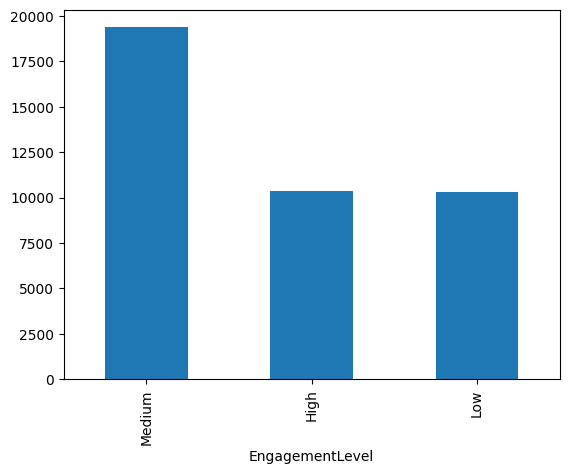

In [8]:
# Target distribution

df['EngagementLevel'].value_counts().plot(kind="bar");

### Data Quality Checks

In [9]:
# MISSING VALUES
df.isnull().sum()

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

In [10]:
# unique values instead of missing
for i in df.columns:
    print({i:df[i].unique()})

{'PlayerID': array([ 9000,  9001,  9002, ..., 49031, 49032, 49033], shape=(40034,))}
{'Age': array([43, 29, 22, 35, 33, 37, 25, 38, 17, 36, 16, 44, 47, 26, 39, 41, 42,
       30, 21, 23, 32, 18, 28, 40, 34, 49, 31, 20, 48, 24, 45, 15, 19, 27,
       46])}
{'Gender': array(['Male', 'Female'], dtype=object)}
{'Location': array(['Other', 'USA', 'Europe', 'Asia'], dtype=object)}
{'GameGenre': array(['Strategy', 'Sports', 'Action', 'RPG', 'Simulation'], dtype=object)}
{'PlayTimeHours': array([16.27111876,  5.52596138,  8.22375524, ...,  0.24005688,
       14.01781798, 10.08380358], shape=(40034,))}
{'InGamePurchases': array([0, 1])}
{'GameDifficulty': array(['Medium', 'Easy', 'Hard'], dtype=object)}
{'SessionsPerWeek': array([ 6,  5, 16,  9,  2,  1, 10, 13,  8,  0,  3,  4, 18, 14, 12, 19, 17,
       11, 15,  7])}
{'AvgSessionDurationMinutes': array([108, 144, 142,  85, 131,  81,  50,  48, 101,  95, 124,  18, 156,
        41, 154, 135,  56, 177, 159, 120, 117, 161,  82, 118,  57, 155,
      

In [11]:
# DUPLICATE RECORDS
df.duplicated().sum()

np.int64(0)

In [12]:
df[df['SessionsPerWeek']==0]['EngagementLevel'].value_counts()

EngagementLevel
Low       1842
High        70
Medium      55
Name: count, dtype: int64

In [13]:
df[(df['SessionsPerWeek']==0) & (df['EngagementLevel']=='Medium')]

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
252,9252,49,Male,USA,Sports,4.680904,0,Medium,0,75,7,36,Medium
738,9738,18,Male,USA,RPG,5.247932,0,Easy,0,122,80,6,Medium
1378,10378,25,Female,Europe,Sports,9.974890,1,Easy,0,56,76,18,Medium
2707,11707,25,Male,USA,RPG,4.579766,0,Easy,0,134,52,38,Medium
2976,11976,43,Male,Asia,Simulation,14.148066,0,Easy,0,12,97,10,Medium
3117,12117,15,Male,USA,Action,3.778183,0,Easy,0,24,31,42,Medium
5115,14115,48,Female,Asia,RPG,14.039261,0,Medium,0,173,38,32,Medium
5825,14825,38,Female,Europe,Strategy,23.804465,0,Medium,0,28,51,31,Medium
5888,14888,37,Male,USA,RPG,22.147706,0,Hard,0,38,62,22,Medium
6591,15591,44,Male,USA,RPG,18.719396,0,Medium,0,174,14,39,Medium


### Exploratory Data Analysis (EDA)

We will do:
- **Univariate analysis**: distribution of each feature
- **Bivariate analysis**: feature vs target
- **Multivariate analysis**: relationships among multiple numeric features

#### Univariate Analysis (Numeric Features)
We'll look at distributions using histograms.

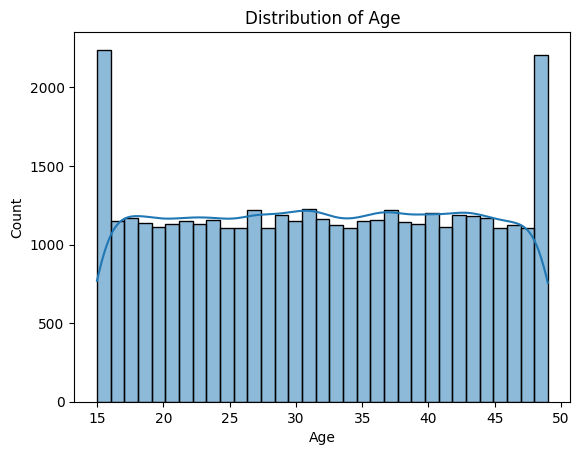

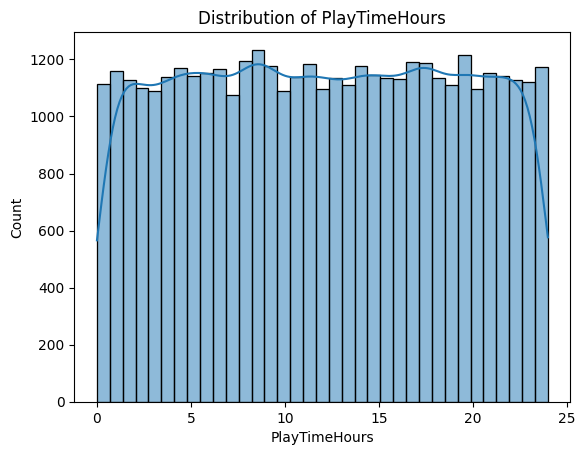

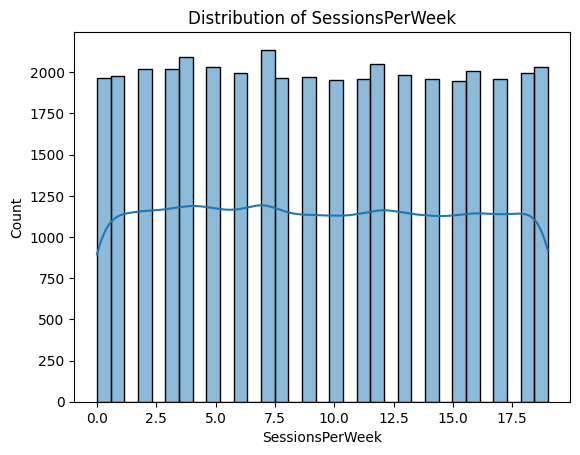

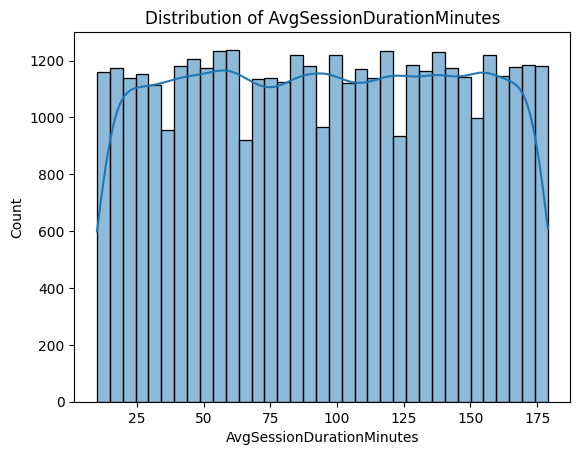

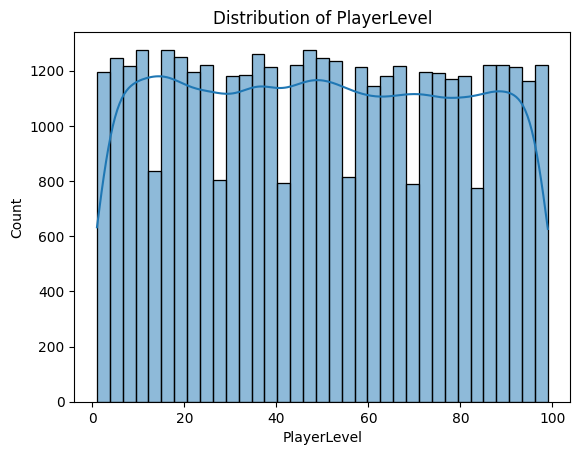

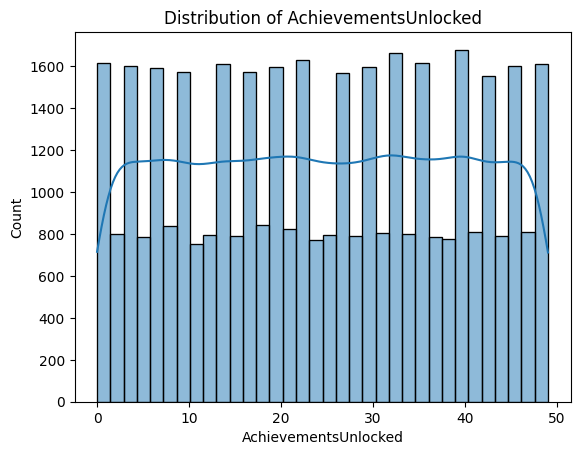

In [14]:
numeric_cols = [
    'Age', 'PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes',
    'PlayerLevel', 'AchievementsUnlocked'
]

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


#### Univariate Analysis (Categorical Features)
We'll look at category counts.

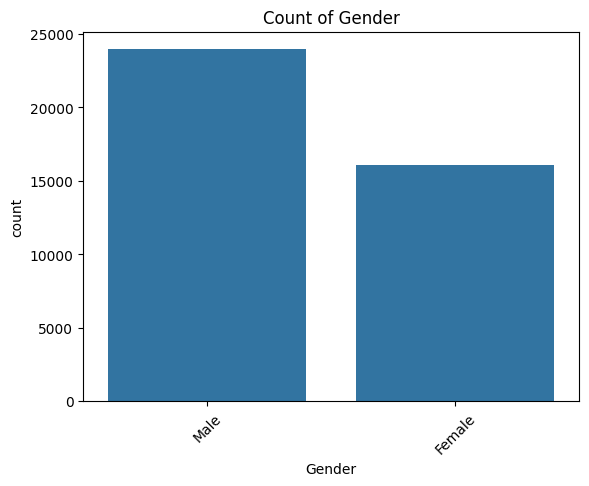

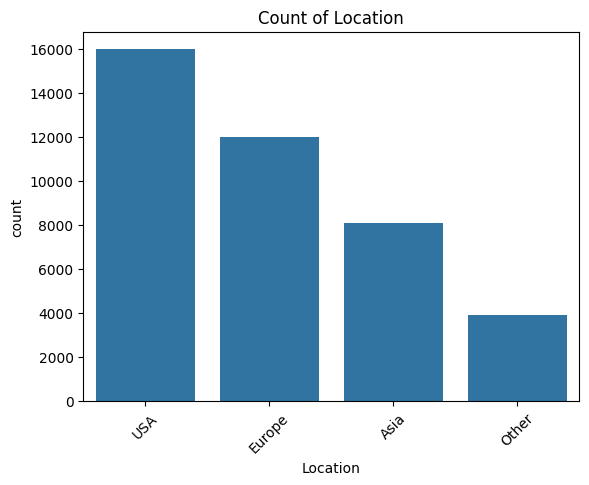

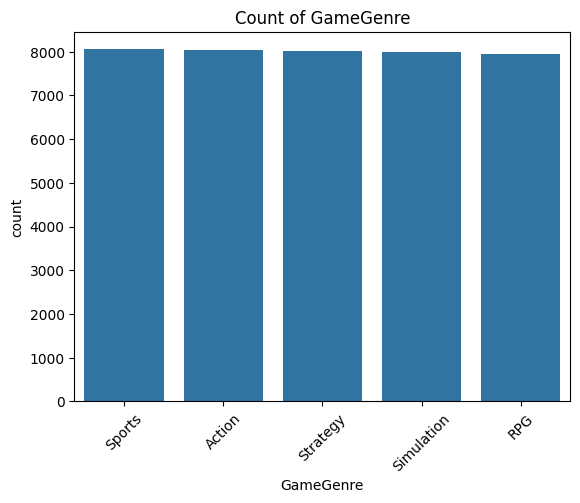

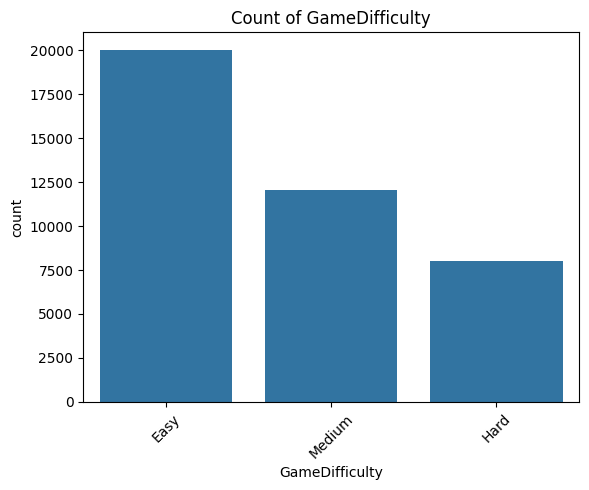

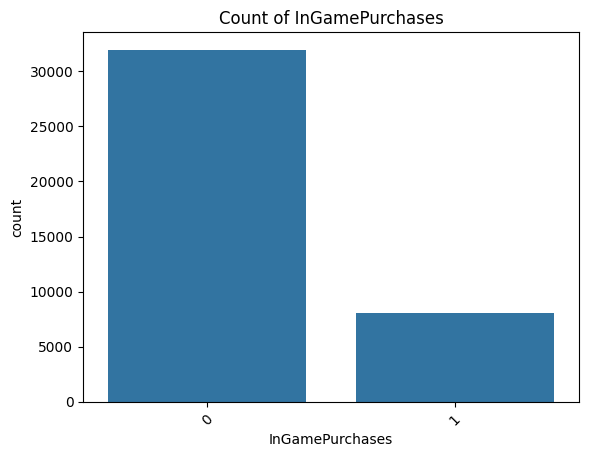

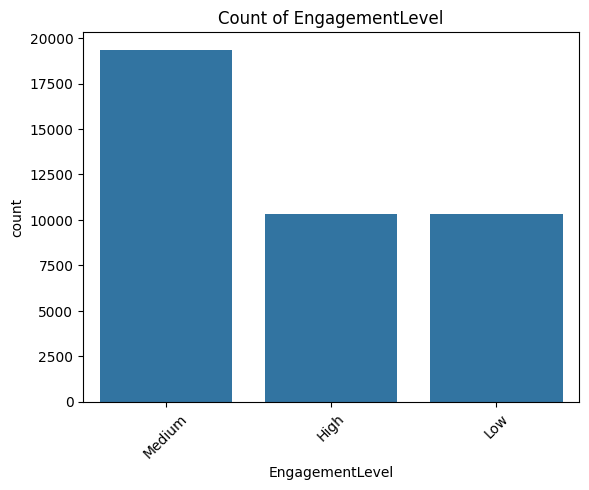

In [15]:
cat_cols = ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'InGamePurchases', 'EngagementLevel']

for col in cat_cols:
    plt.figure()
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()

#### Bivariate Analysis (Feature vs EngagementLevel)
For numeric features we use boxplots. This helps compare distributions across engagement classes.

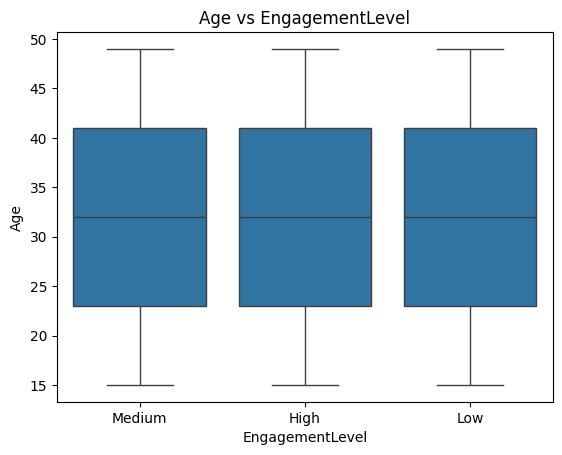

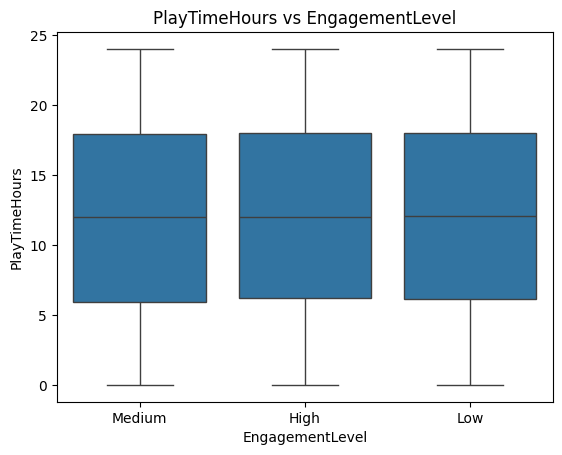

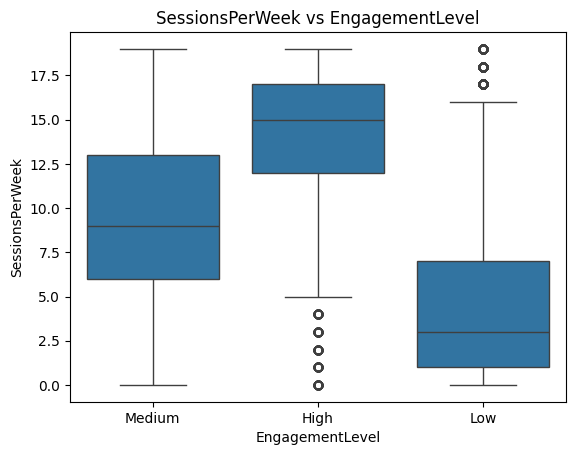

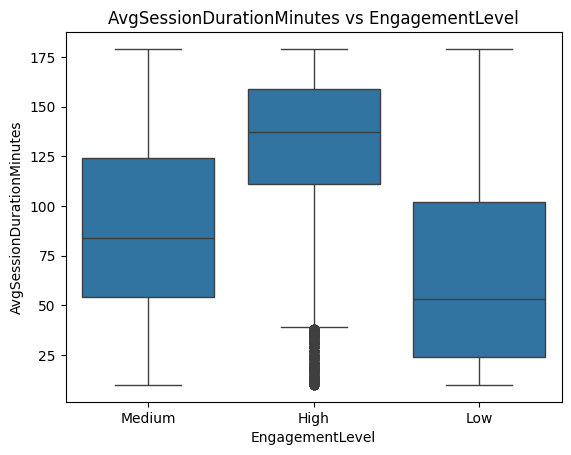

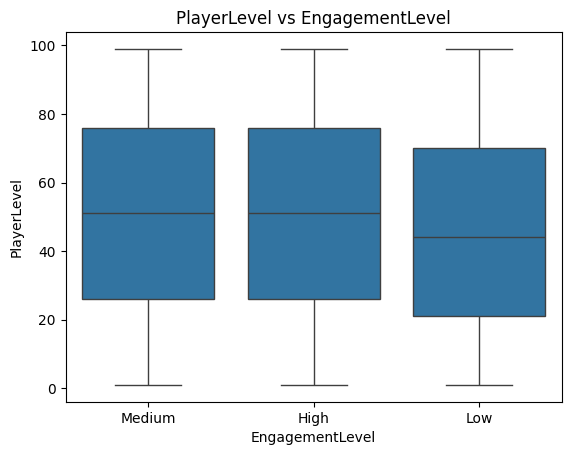

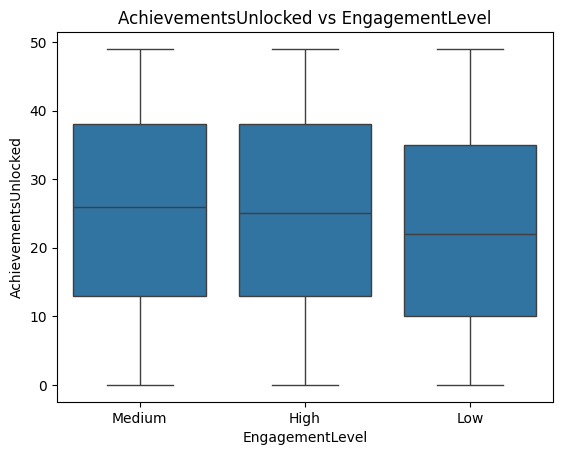

In [16]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(data=df, x='EngagementLevel', y=col)
    plt.title(f'{col} vs EngagementLevel')
    plt.show()


For categorical features we use countplots split by EngagementLevel.

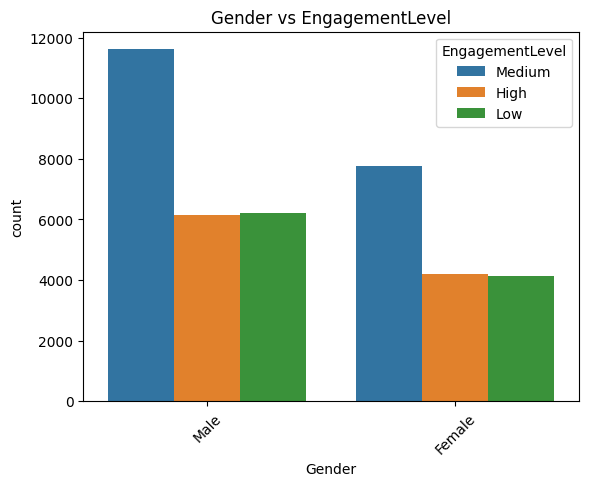

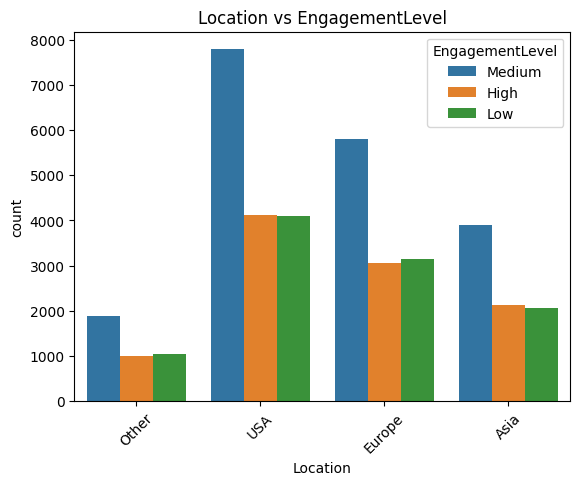

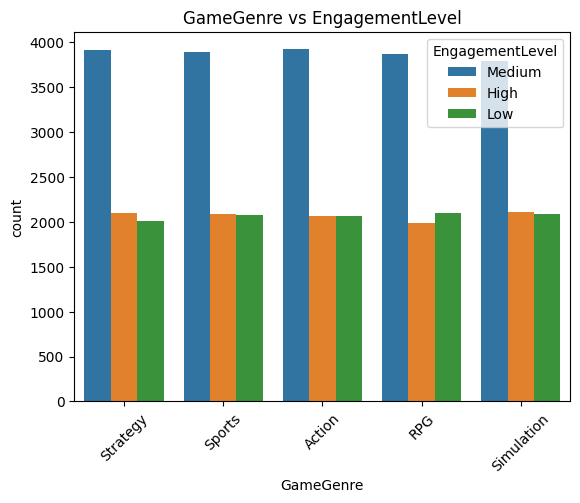

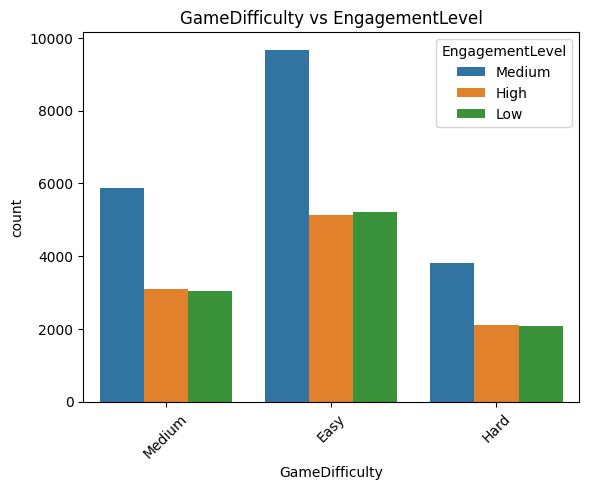

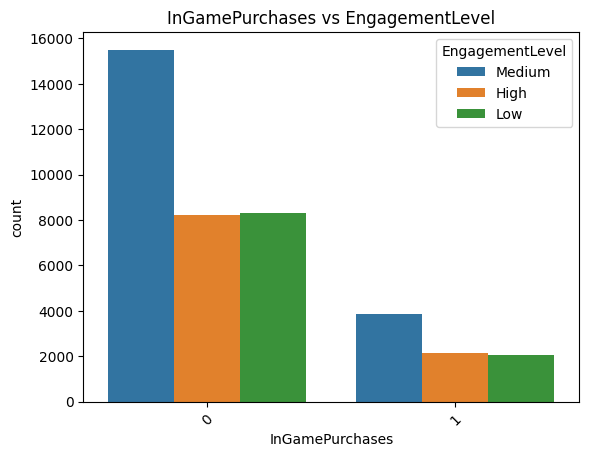

In [17]:
cat_cols_no_target = ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'InGamePurchases']

for col in cat_cols_no_target:
    plt.figure()
    sns.countplot(data=df, x=col, hue='EngagementLevel')
    plt.title(f'{col} vs EngagementLevel')
    plt.xticks(rotation=45)
    plt.legend(title='EngagementLevel')
    plt.show()


#### Multivariate Analysis
We'll check numeric feature relationships using a correlation heatmap.

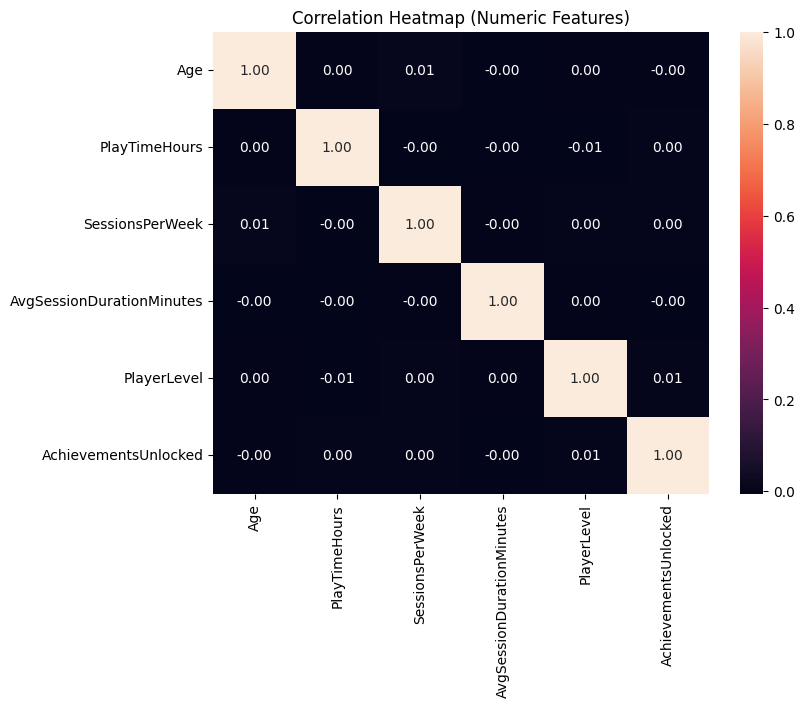

In [18]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()


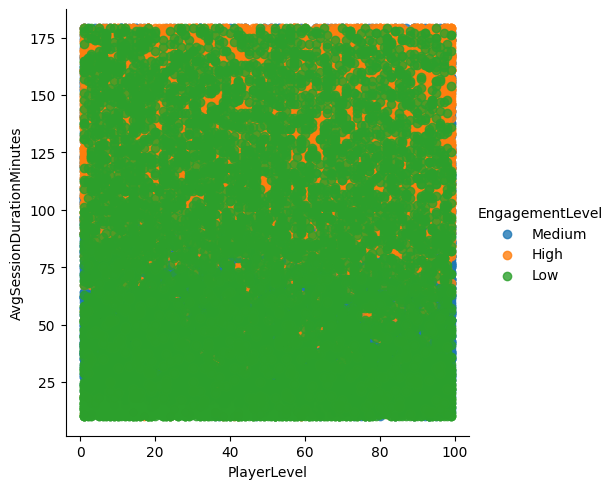

In [19]:
sns.lmplot(data=df ,x='PlayerLevel',y='AvgSessionDurationMinutes',hue='EngagementLevel',fit_reg=False)

### Engineering & Preprocessing

**Decisions:**
1. Drop `PlayerID` (identifier, not a behavioral feature)
2. Separate features (X) and target (y)
3. Split into train/test sets (stratified to preserve class ratios)
4. Encoding categorical features

In [20]:
colname=[]
for x in df.columns:
    if df[x].dtype=='object':
        colname.append(x)
colname

['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'EngagementLevel']

In [21]:
from sklearn.preprocessing import LabelEncoder
le_gen = LabelEncoder()

df['Gender'] = le_gen.fit_transform(df['Gender'])
le_name_mapping = dict(zip(le_gen.classes_, le_gen.transform(le_gen.classes_)))

print('mapping', le_name_mapping)

mapping {'Female': np.int64(0), 'Male': np.int64(1)}


In [22]:
le_loc = LabelEncoder()

df['Location'] = le_loc.fit_transform(df['Location'])
le_name_mapping = dict(zip(le_loc.classes_, le_loc.transform(le_loc.classes_)))

print('mapping', le_name_mapping)

mapping {'Asia': np.int64(0), 'Europe': np.int64(1), 'Other': np.int64(2), 'USA': np.int64(3)}


In [23]:
le_genre = LabelEncoder()

df['GameGenre'] = le_genre.fit_transform(df['GameGenre'])
le_name_mapping = dict(zip(le_genre.classes_, le_genre.transform(le_genre.classes_)))

print('mapping', le_name_mapping)

mapping {'Action': np.int64(0), 'RPG': np.int64(1), 'Simulation': np.int64(2), 'Sports': np.int64(3), 'Strategy': np.int64(4)}


In [24]:
df["GameDifficulty"].unique()

array(['Medium', 'Easy', 'Hard'], dtype=object)

In [25]:
df["GameDifficulty"] = df["GameDifficulty"].map({"Easy":0,'Medium':1,"Hard":2})

In [26]:
df['EngagementLevel'].unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [27]:
df['EngagementLevel'] = df['EngagementLevel'].map({"Low":0,'Medium':1,"High":2})

In [28]:
df

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,1,2,4,16.271119,0,1,6,108,79,25,1
1,9001,29,0,3,4,5.525961,0,1,5,144,11,10,1
2,9002,22,0,3,3,8.223755,0,0,16,142,35,41,2
3,9003,35,1,3,0,5.265351,1,0,9,85,57,47,1
4,9004,33,1,1,0,15.531945,0,1,2,131,95,37,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,1,3,4,20.619662,0,0,4,75,85,14,1
40030,49030,44,0,2,2,13.539280,0,2,19,114,71,27,2
40031,49031,15,0,3,1,0.240057,1,0,10,176,29,1,2
40032,49032,34,1,3,3,14.017818,1,1,3,128,70,10,1


In [29]:
df.isnull().sum()

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

In [30]:
# Drop identifier

df_model = df.drop(columns=['PlayerID'])

X = df_model.drop(columns=['EngagementLevel'])
y = df_model['EngagementLevel']

print('X shape:', X.shape)
print('y distribution:\n', y.value_counts())

X shape: (40034, 11)
y distribution:
 EngagementLevel
1    19374
2    10336
0    10324
Name: count, dtype: int64


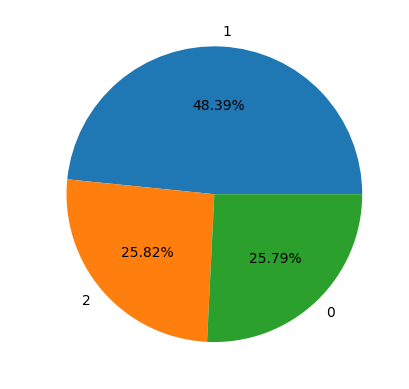

In [31]:
df_model['EngagementLevel'].value_counts().plot(kind='pie',autopct="%.2f%%")
plt.ylabel(" ");

In [32]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (32027, 11) | Test: (8007, 11)


#### Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression
#create a model
classifier=LogisticRegression()
#fitting training data to the model
classifier.fit(X_train,Y_train)

Y_pred=classifier.predict(X_test)
print(Y_pred)

[1 1 1 ... 1 1 1]


In [34]:
np.set_printoptions(suppress= True)
Y_pred_prob=classifier.predict_proba(X_test)
Y_pred_prob

array([[0.03232857, 0.65037826, 0.31729317],
       [0.1054527 , 0.65339074, 0.24115656],
       [0.40474021, 0.55668118, 0.03857862],
       ...,
       [0.1155424 , 0.76409299, 0.12036461],
       [0.15255834, 0.72155657, 0.12588509],
       [0.40723091, 0.56928861, 0.02348048]], shape=(8007, 3))

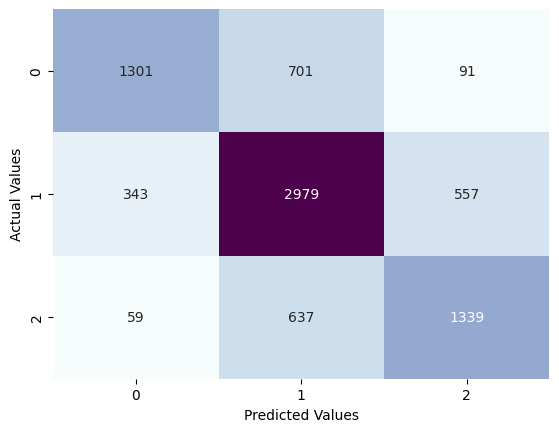

Classification report:
              precision    recall  f1-score   support

           0       0.76      0.62      0.69      2093
           1       0.69      0.77      0.73      3879
           2       0.67      0.66      0.67      2035

    accuracy                           0.70      8007
   macro avg       0.71      0.68      0.69      8007
weighted avg       0.71      0.70      0.70      8007

Accuracy of the model:  0.7017609591607343


In [35]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()


print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [36]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(classifier.score(X_train, Y_train)))

print('Test set score: {:.4f}'.format(classifier.score(X_test, Y_test)))

Training set score: 0.6962
Test set score: 0.7018


### Decision Tree

In [37]:
#predicting using the Decision_Tree_Classifier
from sklearn.tree import DecisionTreeClassifier

model_DecisionTree = DecisionTreeClassifier(criterion="gini",random_state=10)

#fit the model on the data and predict the values
model_DecisionTree.fit(X_train,Y_train)

Y_pred = model_DecisionTree.predict(X_test)
#print(Y_pred)
#print(list(zip(Y_test,Y_pred)))

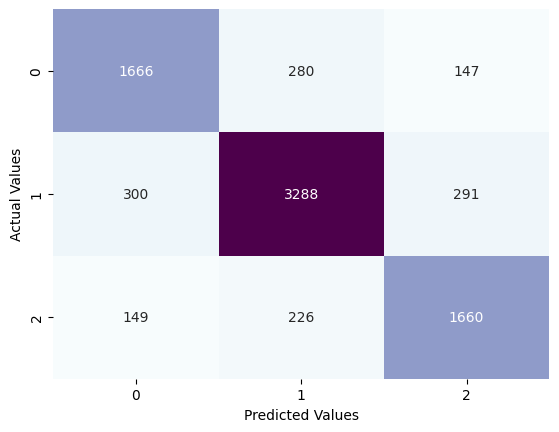

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.79      2093
           1       0.87      0.85      0.86      3879
           2       0.79      0.82      0.80      2035

    accuracy                           0.83      8007
   macro avg       0.82      0.82      0.82      8007
weighted avg       0.83      0.83      0.83      8007

Accuracy of the model:  0.826027226177095


In [38]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

### Observation

- If the model struggles with a class (e.g., `Low`), check **recall** for that class.
- If precision is low for a class, the model is predicting that class too often incorrectly.

Next, we’ll interpret the model using feature importance and tree visualization.


In [39]:
# print the scores on training and test set
print('Training set score: {:.4f}'.format(model_DecisionTree.score(X_train, Y_train)))

print('Test set score: {:.4f}'.format(model_DecisionTree.score(X_test, Y_test)))

Training set score: 1.0000
Test set score: 0.8260


In [40]:
sample=pd.DataFrame()

sample["Column"]=df_model.columns[0:-1]
sample["Imp value"]=model_DecisionTree.feature_importances_

sample.sort_values("Imp value",ascending=False)

,Column,Imp value
7,SessionsPerWeek,0.468552
8,AvgSessionDurationMinutes,0.291614
9,PlayerLevel,0.063271
10,AchievementsUnlocked,0.062050
4,PlayTimeHours,0.046639
0,Age,0.027814
3,GameGenre,0.011831
2,Location,0.009568
6,GameDifficulty,0.007774
1,Gender,0.006268


In [41]:
importances = pd.Series(model_DecisionTree.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=False)

importances_sorted.head(15)

SessionsPerWeek              0.468552
AvgSessionDurationMinutes    0.291614
PlayerLevel                  0.063271
AchievementsUnlocked         0.062050
PlayTimeHours                0.046639
Age                          0.027814
GameGenre                    0.011831
Location                     0.009568
GameDifficulty               0.007774
Gender                       0.006268
InGamePurchases              0.004618
dtype: float64

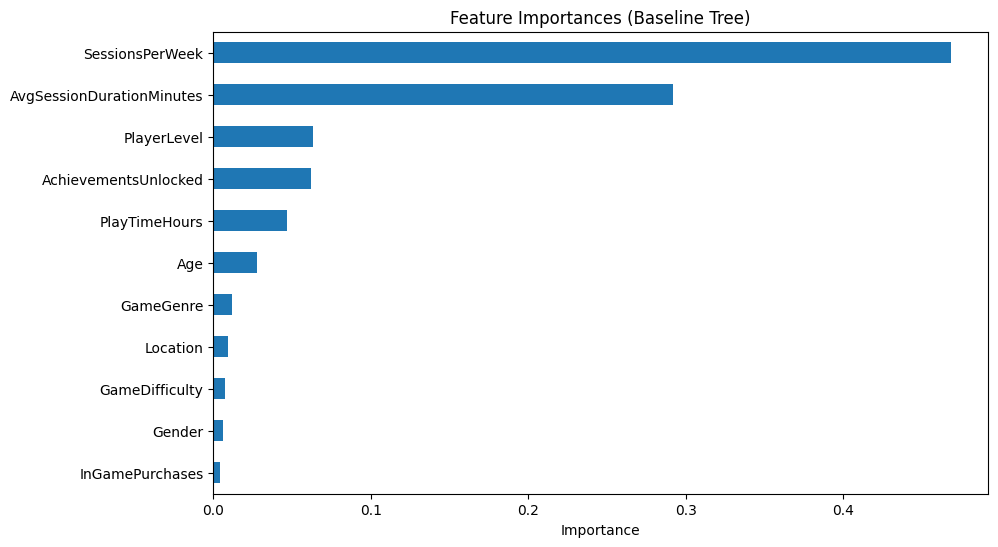

In [42]:
# Plot important features

plt.figure(figsize=(10, 6))
importances_sorted.sort_values().plot(kind='barh')
plt.title('Feature Importances (Baseline Tree)')
plt.xlabel('Importance')
plt.show()


In [43]:
#predicting using the Decision_Tree_Classifier
from sklearn.tree import DecisionTreeClassifier

model_DecisionTree = DecisionTreeClassifier(criterion="gini",random_state=20,
                                           splitter="best",min_samples_leaf=7,
                                           max_depth=15)

#fit the model on the data and predict the values
model_DecisionTree.fit(X_train,Y_train)

Y_pred = model_DecisionTree.predict(X_test)
#print(Y_pred)
#print(list(zip(Y_test,Y_pred)))

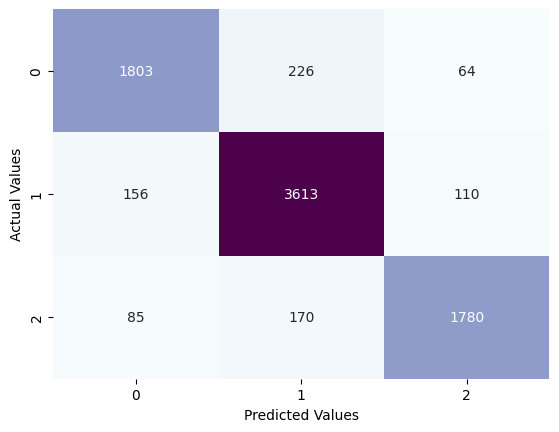

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      2093
           1       0.90      0.93      0.92      3879
           2       0.91      0.87      0.89      2035

    accuracy                           0.90      8007
   macro avg       0.90      0.89      0.89      8007
weighted avg       0.90      0.90      0.90      8007

Accuracy of the model:  0.8987136255776196


In [44]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [45]:
# print the scores on training and test set
print('Training set score: {:.4f}'.format(model_DecisionTree.score(X_train, Y_train)))

print('Test set score: {:.4f}'.format(model_DecisionTree.score(X_test, Y_test)))

Training set score: 0.9248
Test set score: 0.8987


### Ensemble Modelling
Ensemble learning is a method where multiple models are combined instead of using just one. Even if individual models are weak, combining their results gives more accurate and reliable predictions.

* Uses multiple models together to improve overall accuracy.
* Reduces errors by balancing mistakes across models.
* Works on a simple idea similar to combining opinions from a group.

**Bagging (Bootstrap Aggregating):** Models are trained independently on different random subsets of the training data. Their results are then combined—usually by averaging (for regression) or voting (for classification). This helps reduce variance and prevents overfitting.

In [46]:
#predicting using the Random_Forest_Classifier
from sklearn.ensemble import RandomForestClassifier

model_RandomForest=RandomForestClassifier(n_estimators=88,max_depth=15,criterion='entropy',min_samples_leaf=1,
                                          random_state=10, bootstrap=True)

#fit the model on the data and predict the values
model_RandomForest.fit(X_train,Y_train)

Y_pred=model_RandomForest.predict(X_test)

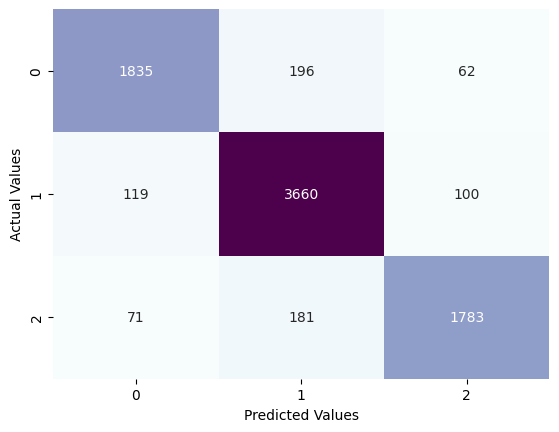

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      2093
           1       0.91      0.94      0.92      3879
           2       0.92      0.88      0.90      2035

    accuracy                           0.91      8007
   macro avg       0.91      0.90      0.90      8007
weighted avg       0.91      0.91      0.91      8007

Accuracy of the model:  0.9089546646684151


In [47]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [48]:
# print the scores on training and test set
print('Training set score: {:.4f}'.format(model_RandomForest.score(X_train, Y_train)))

print('Test set score: {:.4f}'.format(model_RandomForest.score(X_test, Y_test)))

Training set score: 0.9621
Test set score: 0.9090


In [49]:
from sklearn.ensemble import ExtraTreesClassifier

model_ExtraTrees = ExtraTreesClassifier(n_estimators=55,random_state=42)

#fit the model on the data and predict the values
model_ExtraTrees.fit(X_train,Y_train)

Y_pred = model_ExtraTrees.predict(X_test)

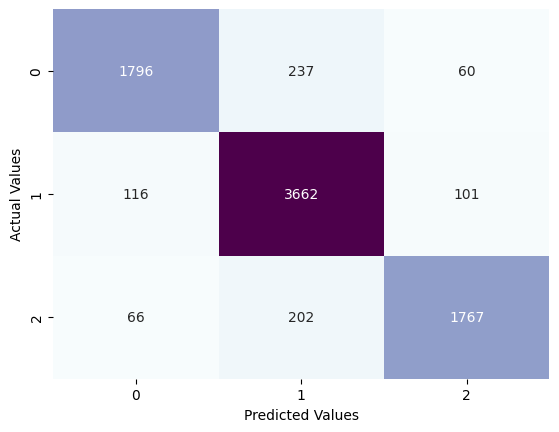

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      2093
           1       0.89      0.94      0.92      3879
           2       0.92      0.87      0.89      2035

    accuracy                           0.90      8007
   macro avg       0.91      0.89      0.90      8007
weighted avg       0.90      0.90      0.90      8007

Accuracy of the model:  0.9023354564755839


In [50]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [51]:
# print the scores on training and test set
print('Training set score: {:.4f}'.format(model_ExtraTrees.score(X_train, Y_train)))

print('Test set score: {:.4f}'.format(model_ExtraTrees.score(X_test, Y_test)))

Training set score: 1.0000
Test set score: 0.9023


In [52]:
model_RandomForest=RandomForestClassifier( random_state=10, bootstrap=True) #fixed parameters should be passsed here

#parameters for trial and error should be passed here
parameter_space = {
    'n_estimators':[100,300,500,1000],       
    'max_depth':[10,15,8, 12],
    'min_samples_leaf':[1,3,4,5,6,7]
    }
from sklearn.model_selection import RandomizedSearchCV #RandomizedSearchCV
clf = RandomizedSearchCV(model_RandomForest, parameter_space, n_jobs=-1, cv=5)

In [53]:
clf.fit(X_train,Y_train)

,estimator,RandomForestC...ndom_state=10)
,param_distributions,"{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [100, 300, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [54]:
print('Best parameters found:\n', clf.best_params_)

Best parameters found:
 {'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 15}


In [55]:
clf.best_score_

np.float64(0.9069220283579773)

In [56]:
Y_pred=clf.predict(X_test)

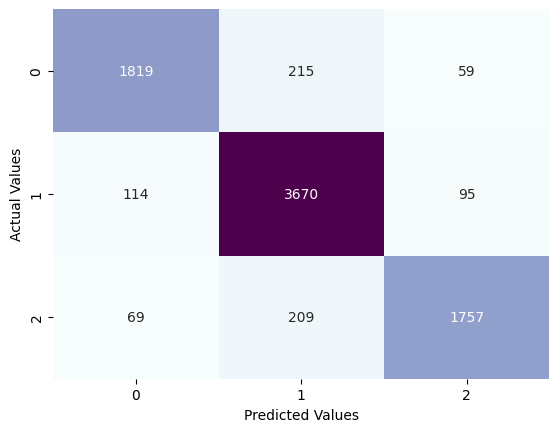

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      2093
           1       0.90      0.95      0.92      3879
           2       0.92      0.86      0.89      2035

    accuracy                           0.90      8007
   macro avg       0.91      0.89      0.90      8007
weighted avg       0.91      0.90      0.90      8007

Accuracy of the model:  0.9049581616085924


In [57]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

**Boosting:** Models are trained one after another. Each new model focuses on fixing the errors made by the previous ones. The final prediction is a weighted combination of all models, which helps reduce bias and improve accuracy.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

model_AdaBoost = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=10),
                                    n_estimators=10,
                                    random_state=10)

# Fit the model on the data and predict the values
model_AdaBoost.fit(X_train, Y_train)
Y_pred = model_AdaBoost.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
model_XGBoost=XGBClassifier(n_estimators=500,learning_rate=0.7,booster="gbtree",max_depth=30,
                              random_state=10)

#fit the model on the data and predict the values
model_XGBoost.fit(X_train,Y_train)

Y_pred=model_XGBoost.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

A **Voting Classifier** is an ensemble machine learning meta-estimator that combines multiple base models (e.g., Logistic Regression, SVM, Random Forest) to produce an improved, more robust model.

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
model1 = LogisticRegression(random_state=42)
model2 = DecisionTreeClassifier(random_state=42)
model3 = SVC(probability=True, random_state=42)  # Enable probability for soft voting

In [ ]:
# Hard Voting Classifier
hard_voting = VotingClassifier(
    estimators=[('lr', model1), ('dt', model2), ('svc', model3)],
    voting='hard'
)

# Soft Voting Classifier
soft_voting = VotingClassifier(
    estimators=[('lr', model1), ('dt', model2), ('svc', model3)],
    voting='soft'
)

In [ ]:
hard_voting.fit(X_train, Y_train)
Y_pred = hard_voting.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)